In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from scipy.stats import boxcox
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline


In [8]:
df = pd.read_csv("cardiac arrest dataset.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [9]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [11]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

features_to_convert = [feature for feature in df.columns if feature not in continuous_features]

df[features_to_convert] = df[features_to_convert].astype('object')

df.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs          object
restecg      object
thalach       int64
exang        object
oldpeak     float64
slope        object
ca           object
thal         object
target       object
dtype: object

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [14]:
df.describe(include='object')

,sex,cp,fbs,restecg,exang,slope,ca,thal,target
count,1025,1025,1025,1025,1025,1025,1025,1025,1025
unique,2,4,2,3,2,3,5,4,2
top,1,0,0,1,0,1,0,2,1
freq,713,497,872,513,680,482,578,544,526


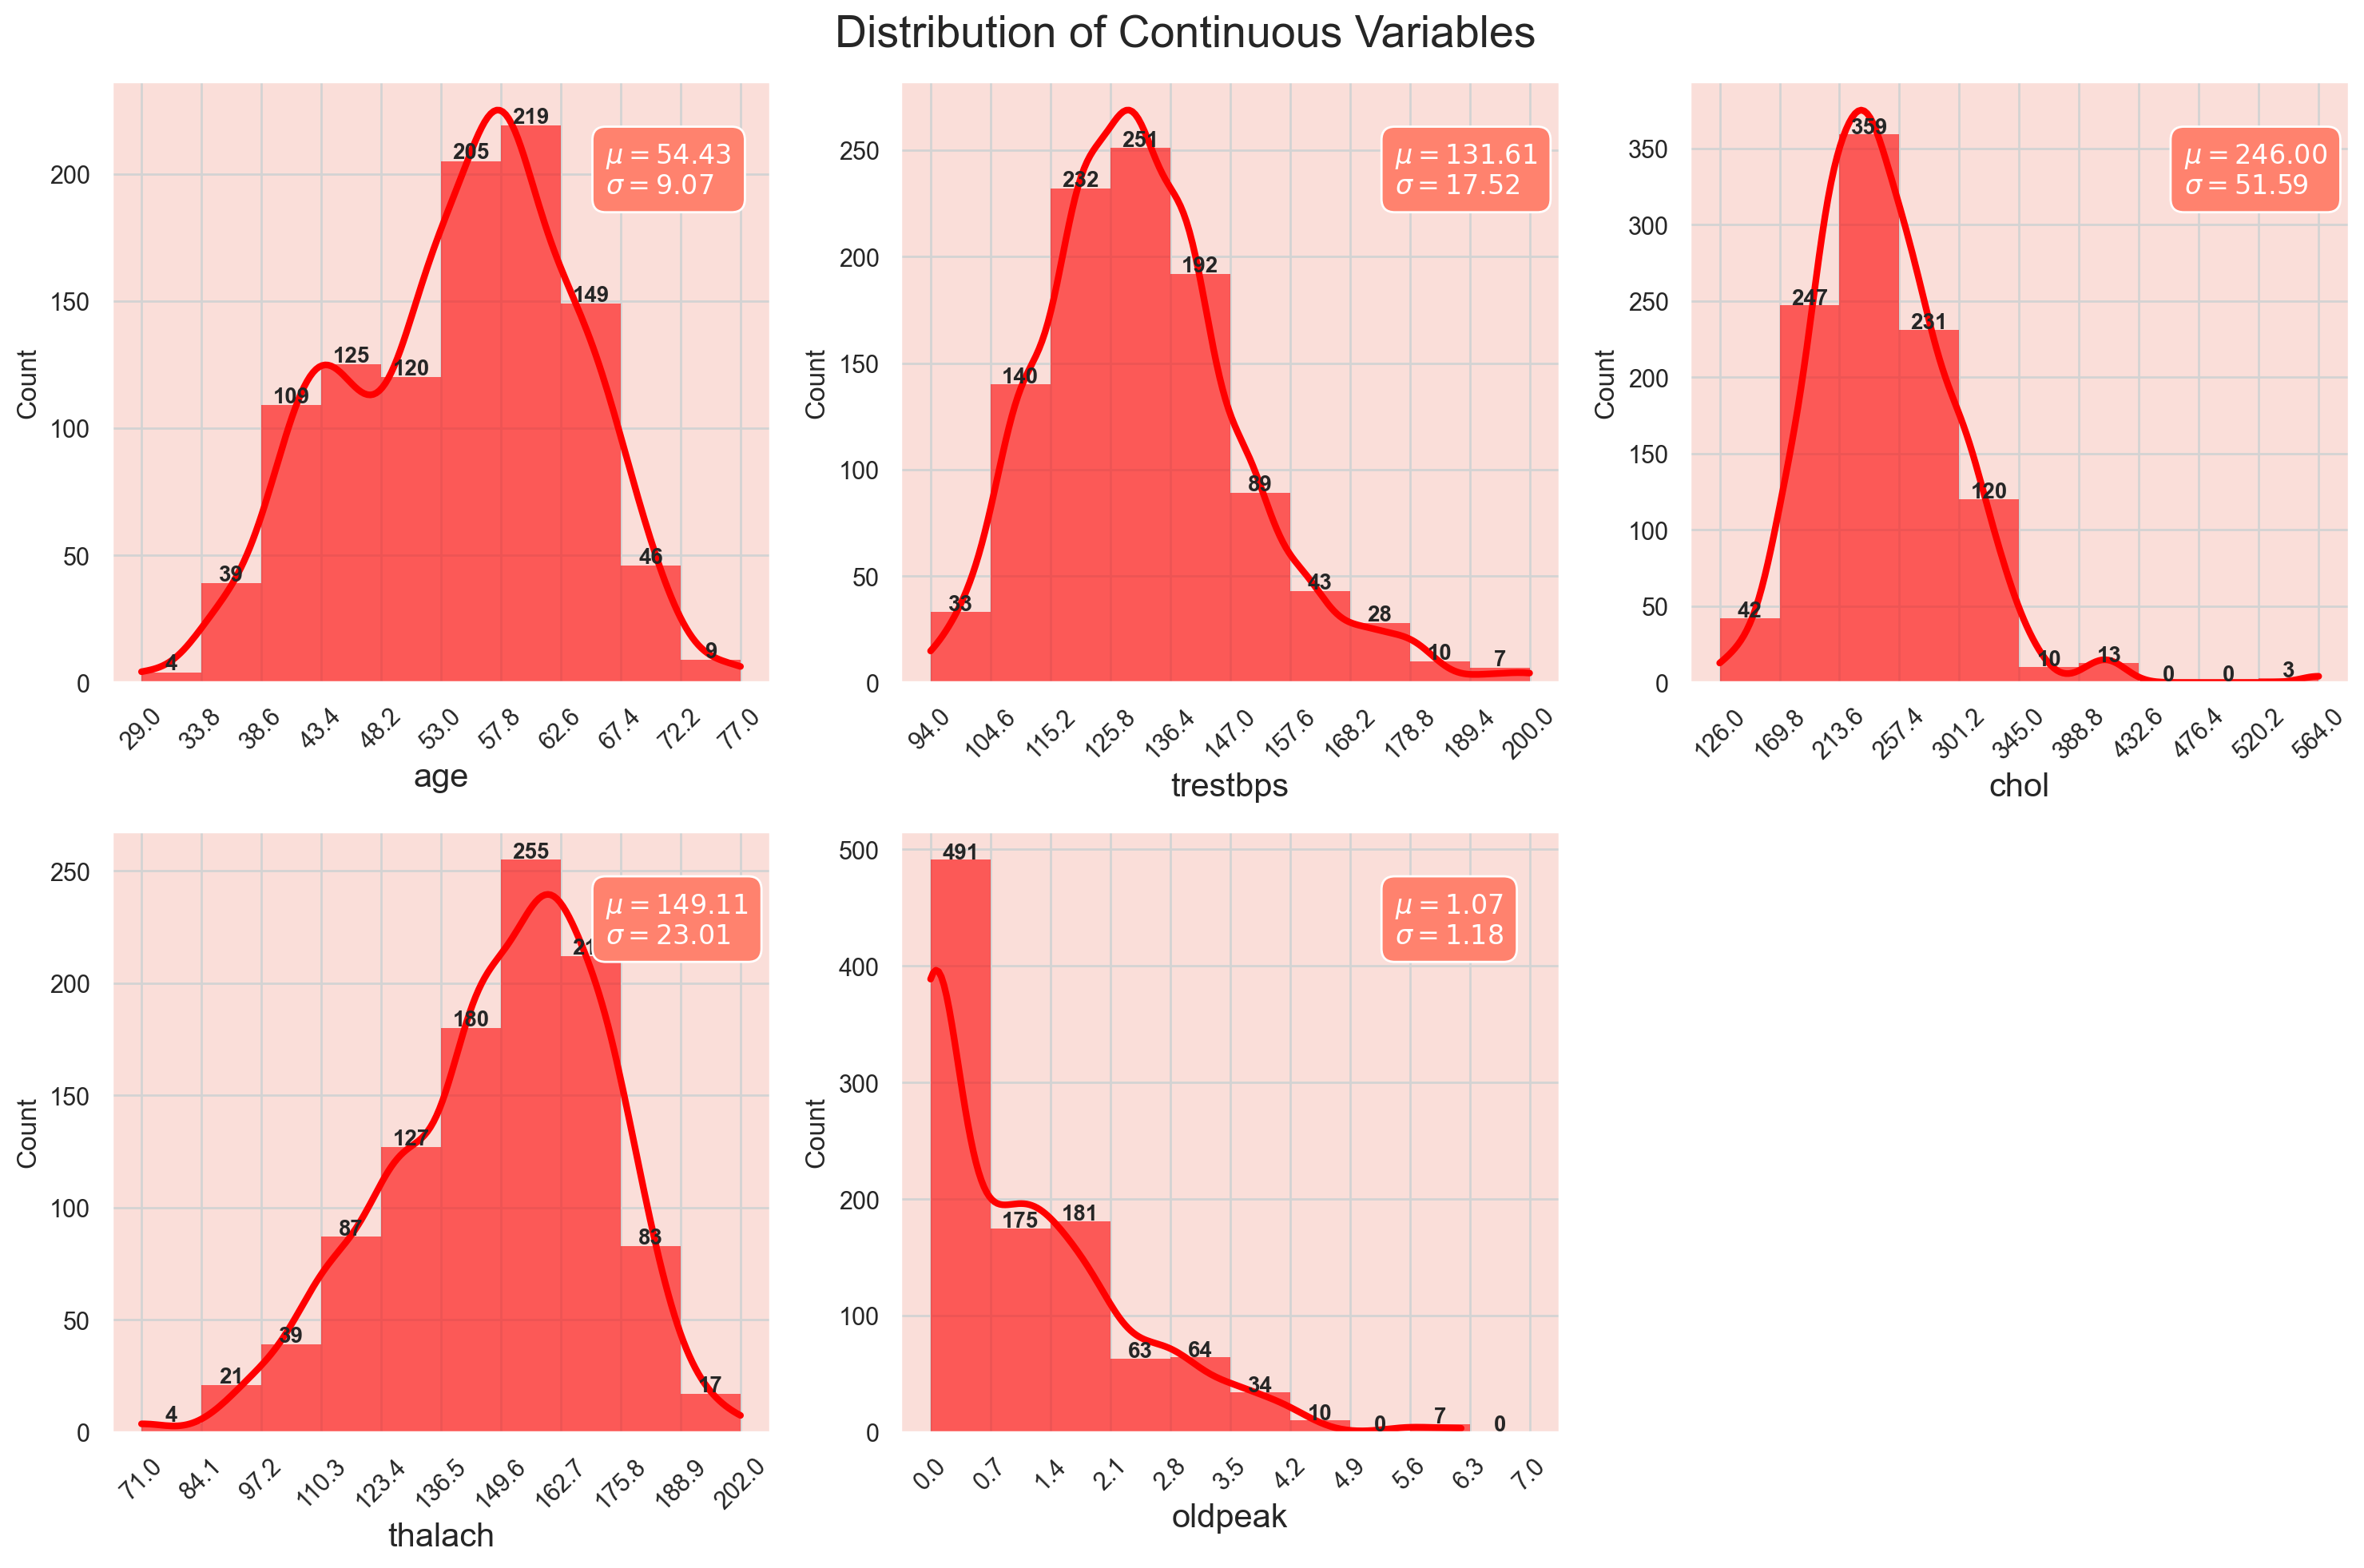

In [18]:
df_continuous = df[continuous_features]

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

for i, col in enumerate(df_continuous.columns):
    x = i // 3
    y = i % 3

    values, bin_edges = np.histogram(
        df_continuous[col],
        range=(
            np.floor(df_continuous[col].min()),
            np.ceil(df_continuous[col].max())
        )
    )

    graph = sns.histplot(
        data=df_continuous,
        x=col,
        bins=bin_edges,
        kde=True,
        ax=ax[x, y],
        edgecolor='none',
        color='red',
        alpha=0.6,
        line_kws={'lw': 3}
    )

    ax[x, y].set_xlabel(col, fontsize=15)
    ax[x, y].set_ylabel('Count', fontsize=12)
    ax[x, y].set_xticks(np.round(bin_edges, 1))
    ax[x, y].set_xticklabels(ax[x, y].get_xticks(), rotation=45)
    ax[x, y].grid(color='lightgrey')

    for p in graph.patches:
        ax[x, y].annotate(
            '{}'.format(int(p.get_height())),
            (p.get_x() + p.get_width() / 2, p.get_height() + 1),
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    textstr = '\n'.join((
        r'$\mu=%.2f$' % df_continuous[col].mean(),
        r'$\sigma=%.2f$' % df_continuous[col].std()
    ))

    ax[x, y].text(
        0.75,
        0.9,
        textstr,
        transform=ax[x, y].transAxes,
        fontsize=12,
        verticalalignment='top',
        color='white',
        bbox=dict(
            boxstyle='round',
            facecolor='#ff826e',
            edgecolor='white',
            pad=0.5
        )
    )

ax[1, 2].axis('off')

plt.suptitle('Distribution of Continuous Variables', fontsize=20)
plt.tight_layout()
plt.show()

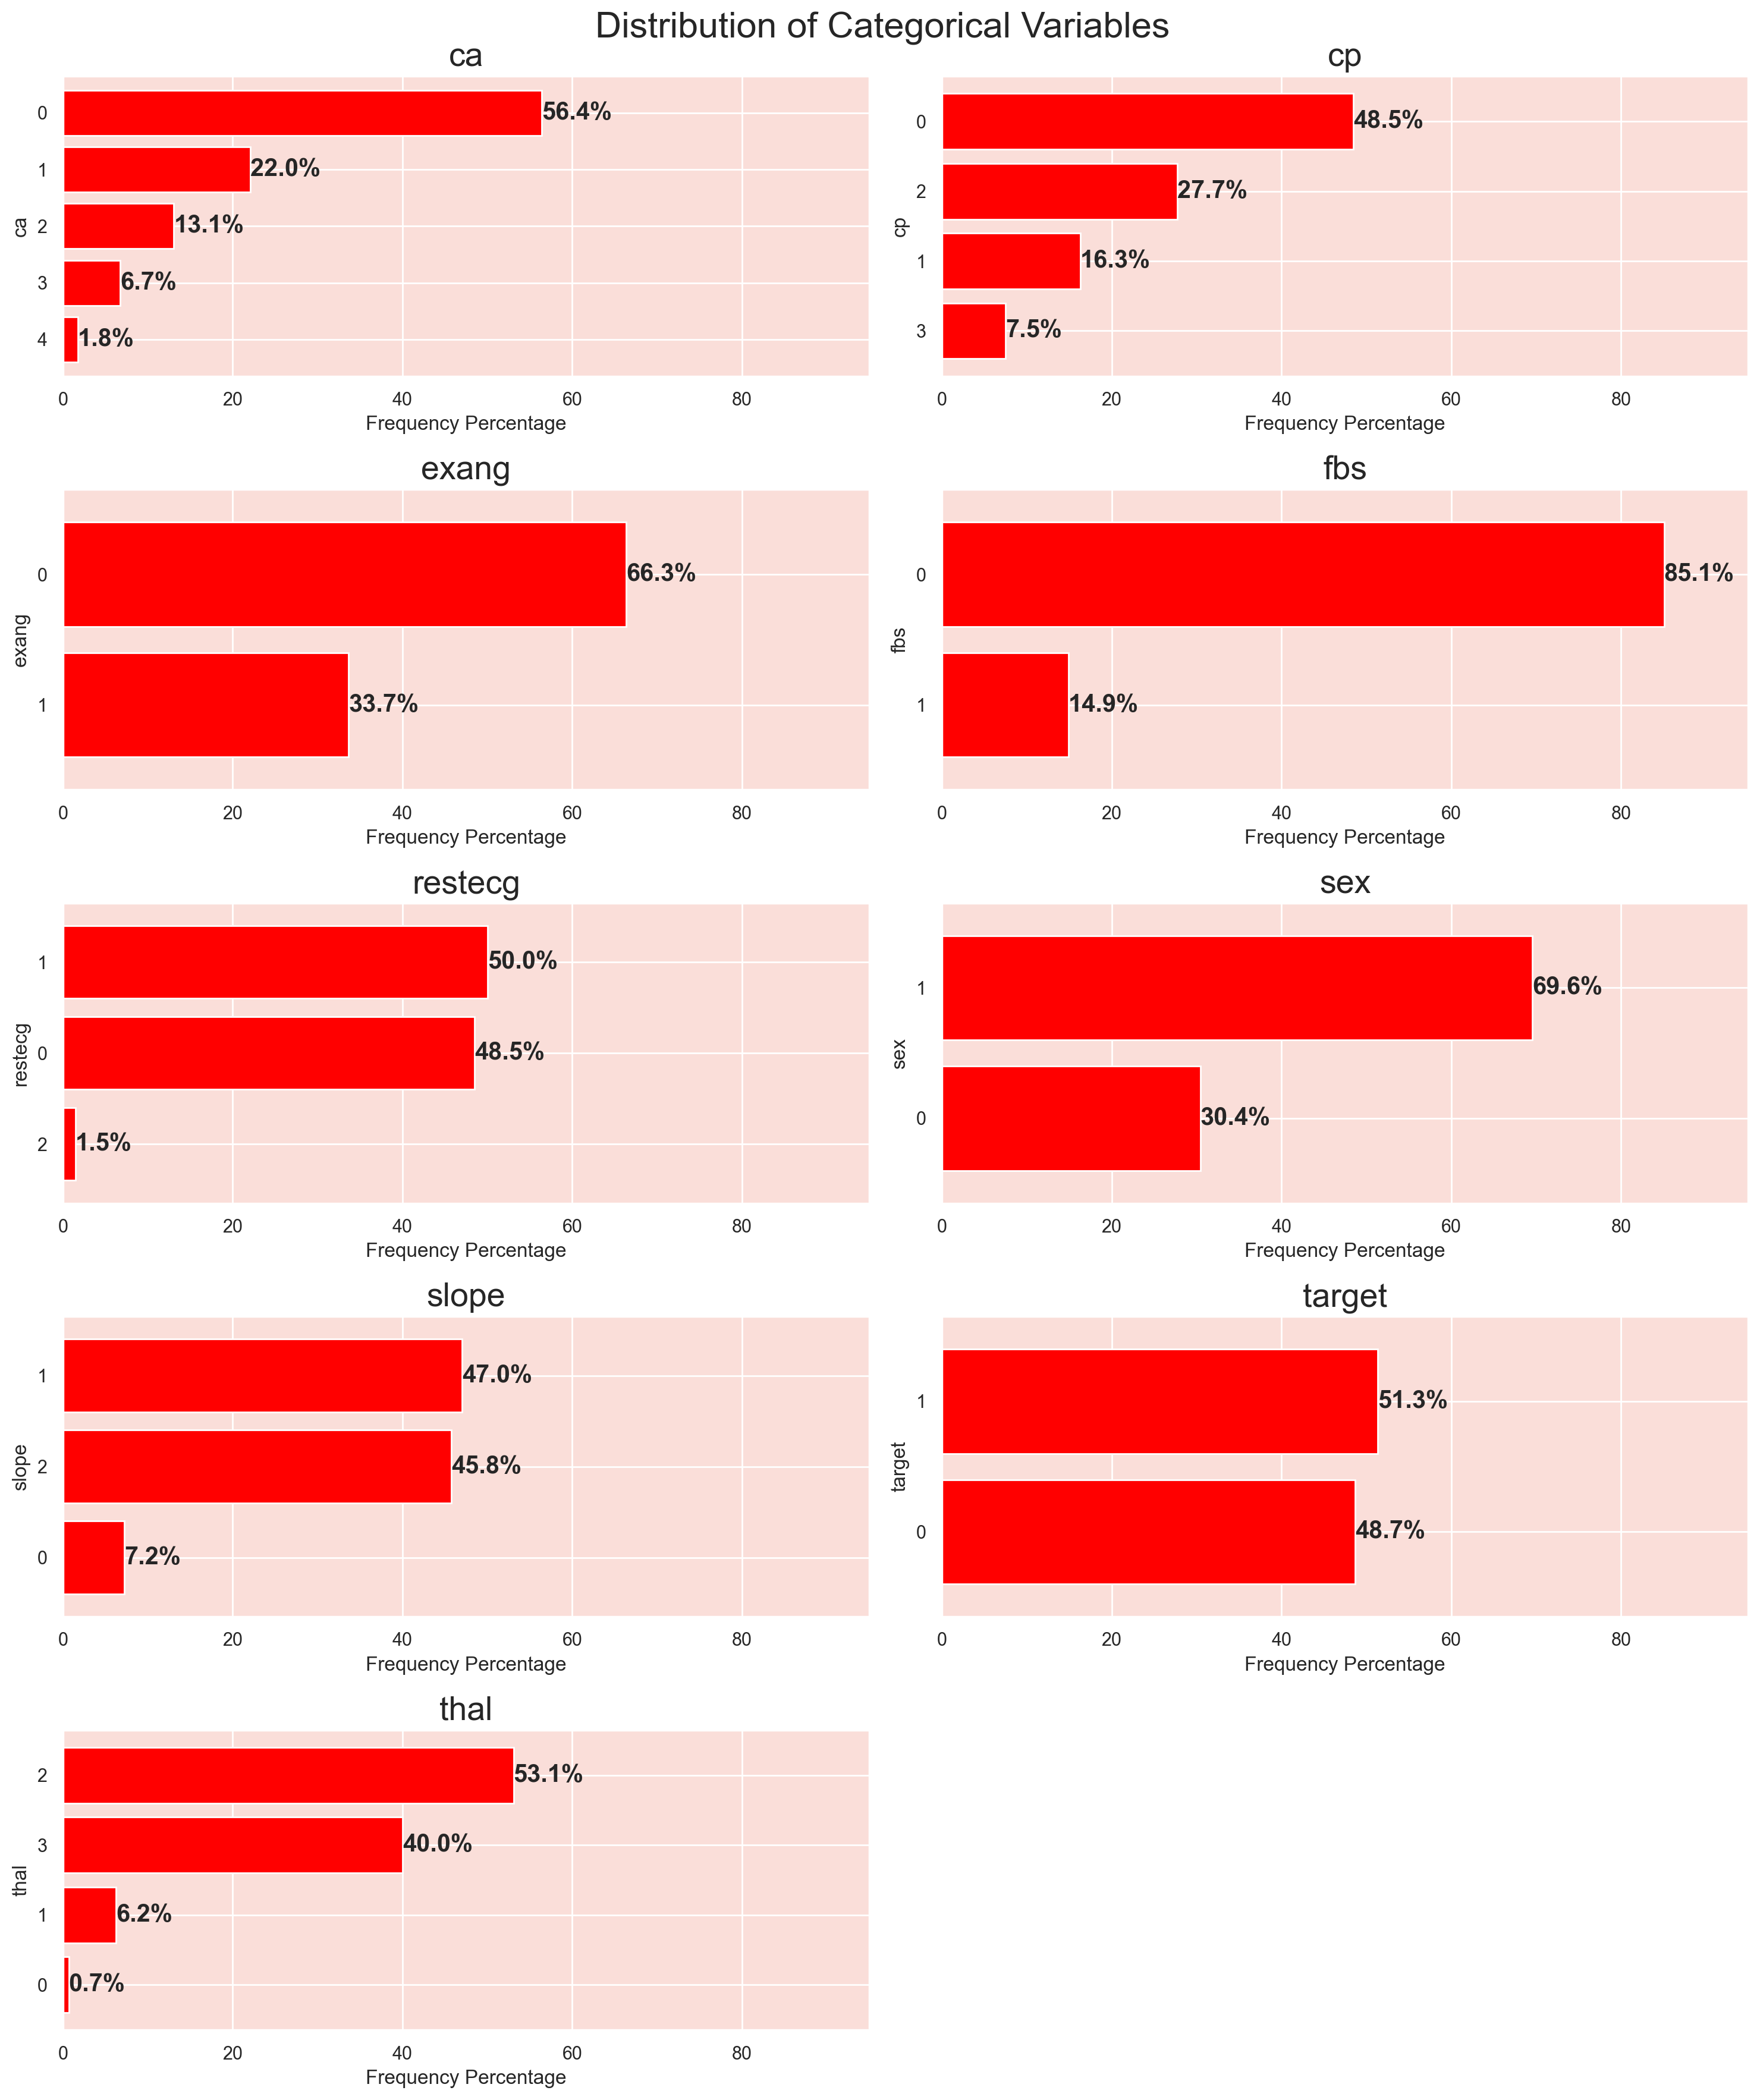

In [19]:
categorical_features = df.columns.difference(continuous_features)
df_categorical = df[categorical_features]

fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(15, 18))

for i, col in enumerate(categorical_features):
    row = i // 2
    col_idx = i % 2

    value_counts = df[col].value_counts(normalize=True).mul(100).sort_values()

    value_counts.plot(
        kind='barh',
        ax=ax[row, col_idx],
        width=0.8,
        color='red'
    )

    for index, value in enumerate(value_counts):
        ax[row, col_idx].text(
            value,
            index,
            str(round(value, 1)) + '%',
            fontsize=15,
            weight='bold',
            va='center'
        )

    ax[row, col_idx].set_xlim([0, 95])
    ax[row, col_idx].set_xlabel('Frequency Percentage', fontsize=12)
    ax[row, col_idx].set_title(f'{col}', fontsize=20)

ax[4, 1].axis('off')

plt.suptitle('Distribution of Categorical Variables', fontsize=22)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

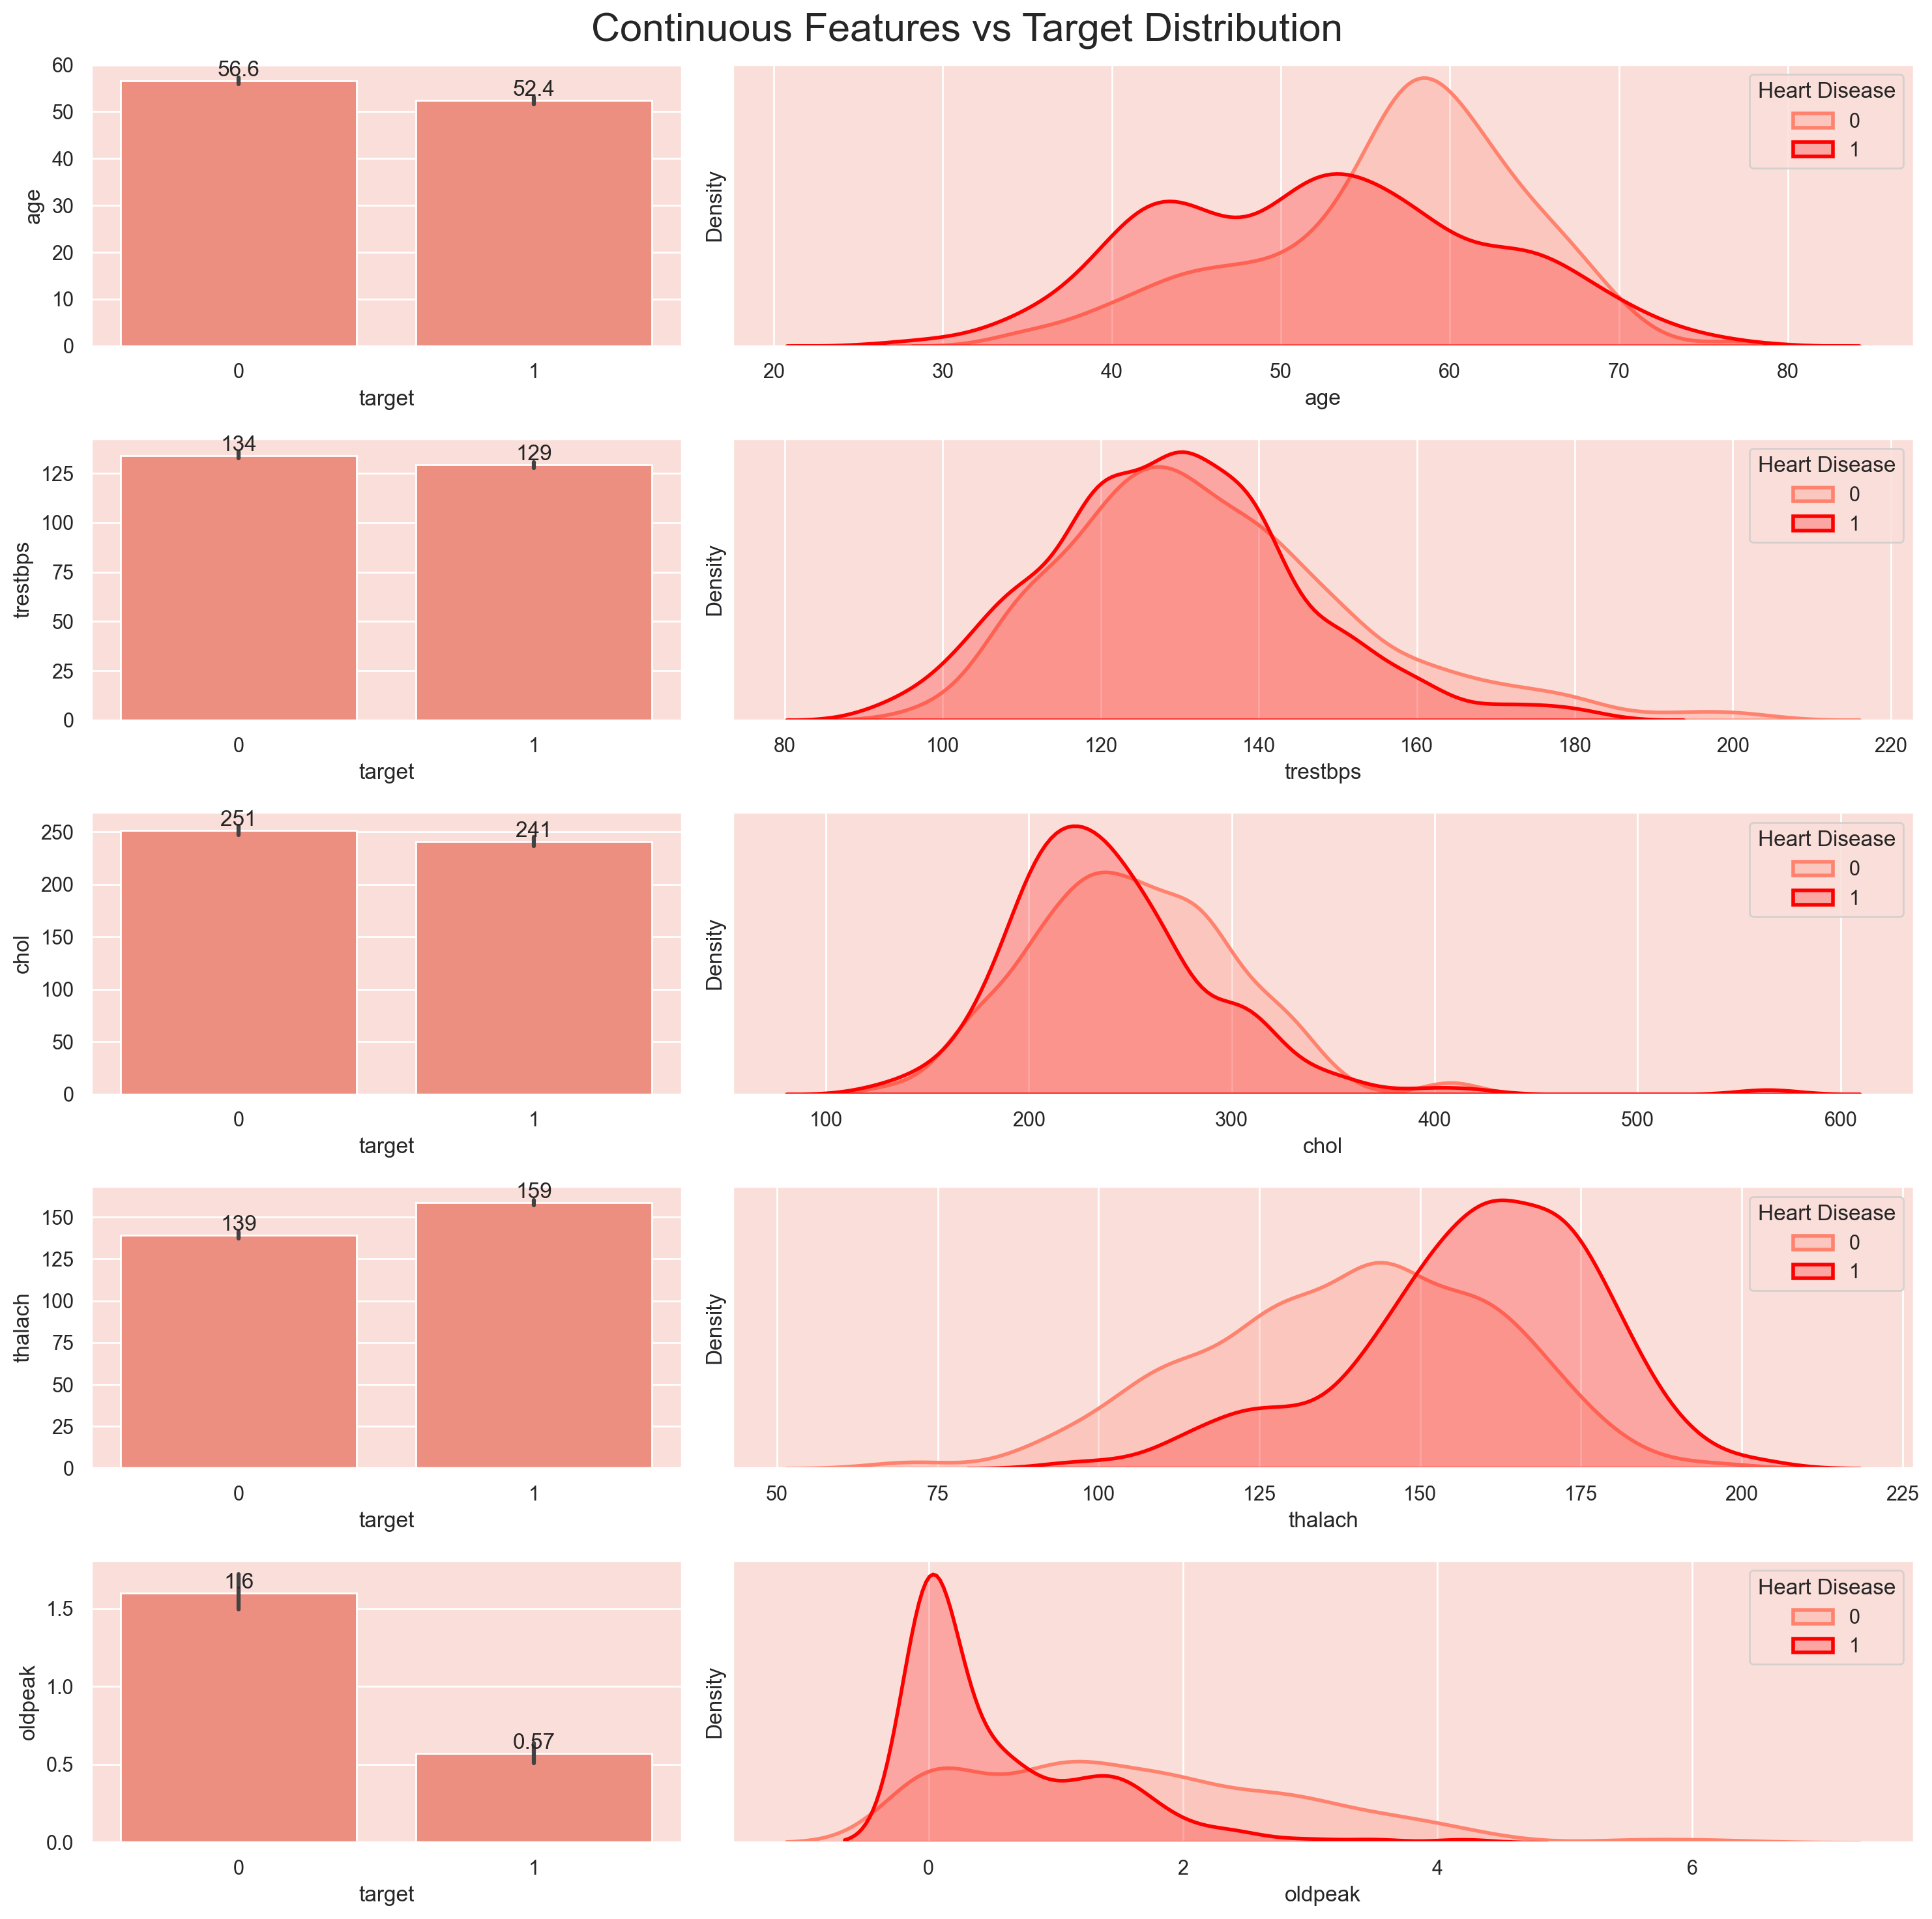

In [20]:
sns.set_palette(['#ff826e', 'red'])

fig, ax = plt.subplots(
    len(continuous_features),
    2,
    figsize=(15, 15),
    gridspec_kw={'width_ratios': [1, 2]}
)

for i, col in enumerate(continuous_features):

    graph = sns.barplot(
        data=df,
        x='target',
        y=col,
        ax=ax[i, 0]
    )

    sns.kdeplot(
        data=df[df['target'] == 0],
        x=col,
        fill=True,
        linewidth=2,
        ax=ax[i, 1],
        label='0'
    )

    sns.kdeplot(
        data=df[df['target'] == 1],
        x=col,
        fill=True,
        linewidth=2,
        ax=ax[i, 1],
        label='1'
    )

    ax[i, 1].set_yticks([])
    ax[i, 1].legend(title='Heart Disease', loc='upper right')

    for cont in graph.containers:
        graph.bar_label(cont, fmt='%.3g')

plt.suptitle('Continuous Features vs Target Distribution', fontsize=22)
plt.tight_layout()
plt.show()

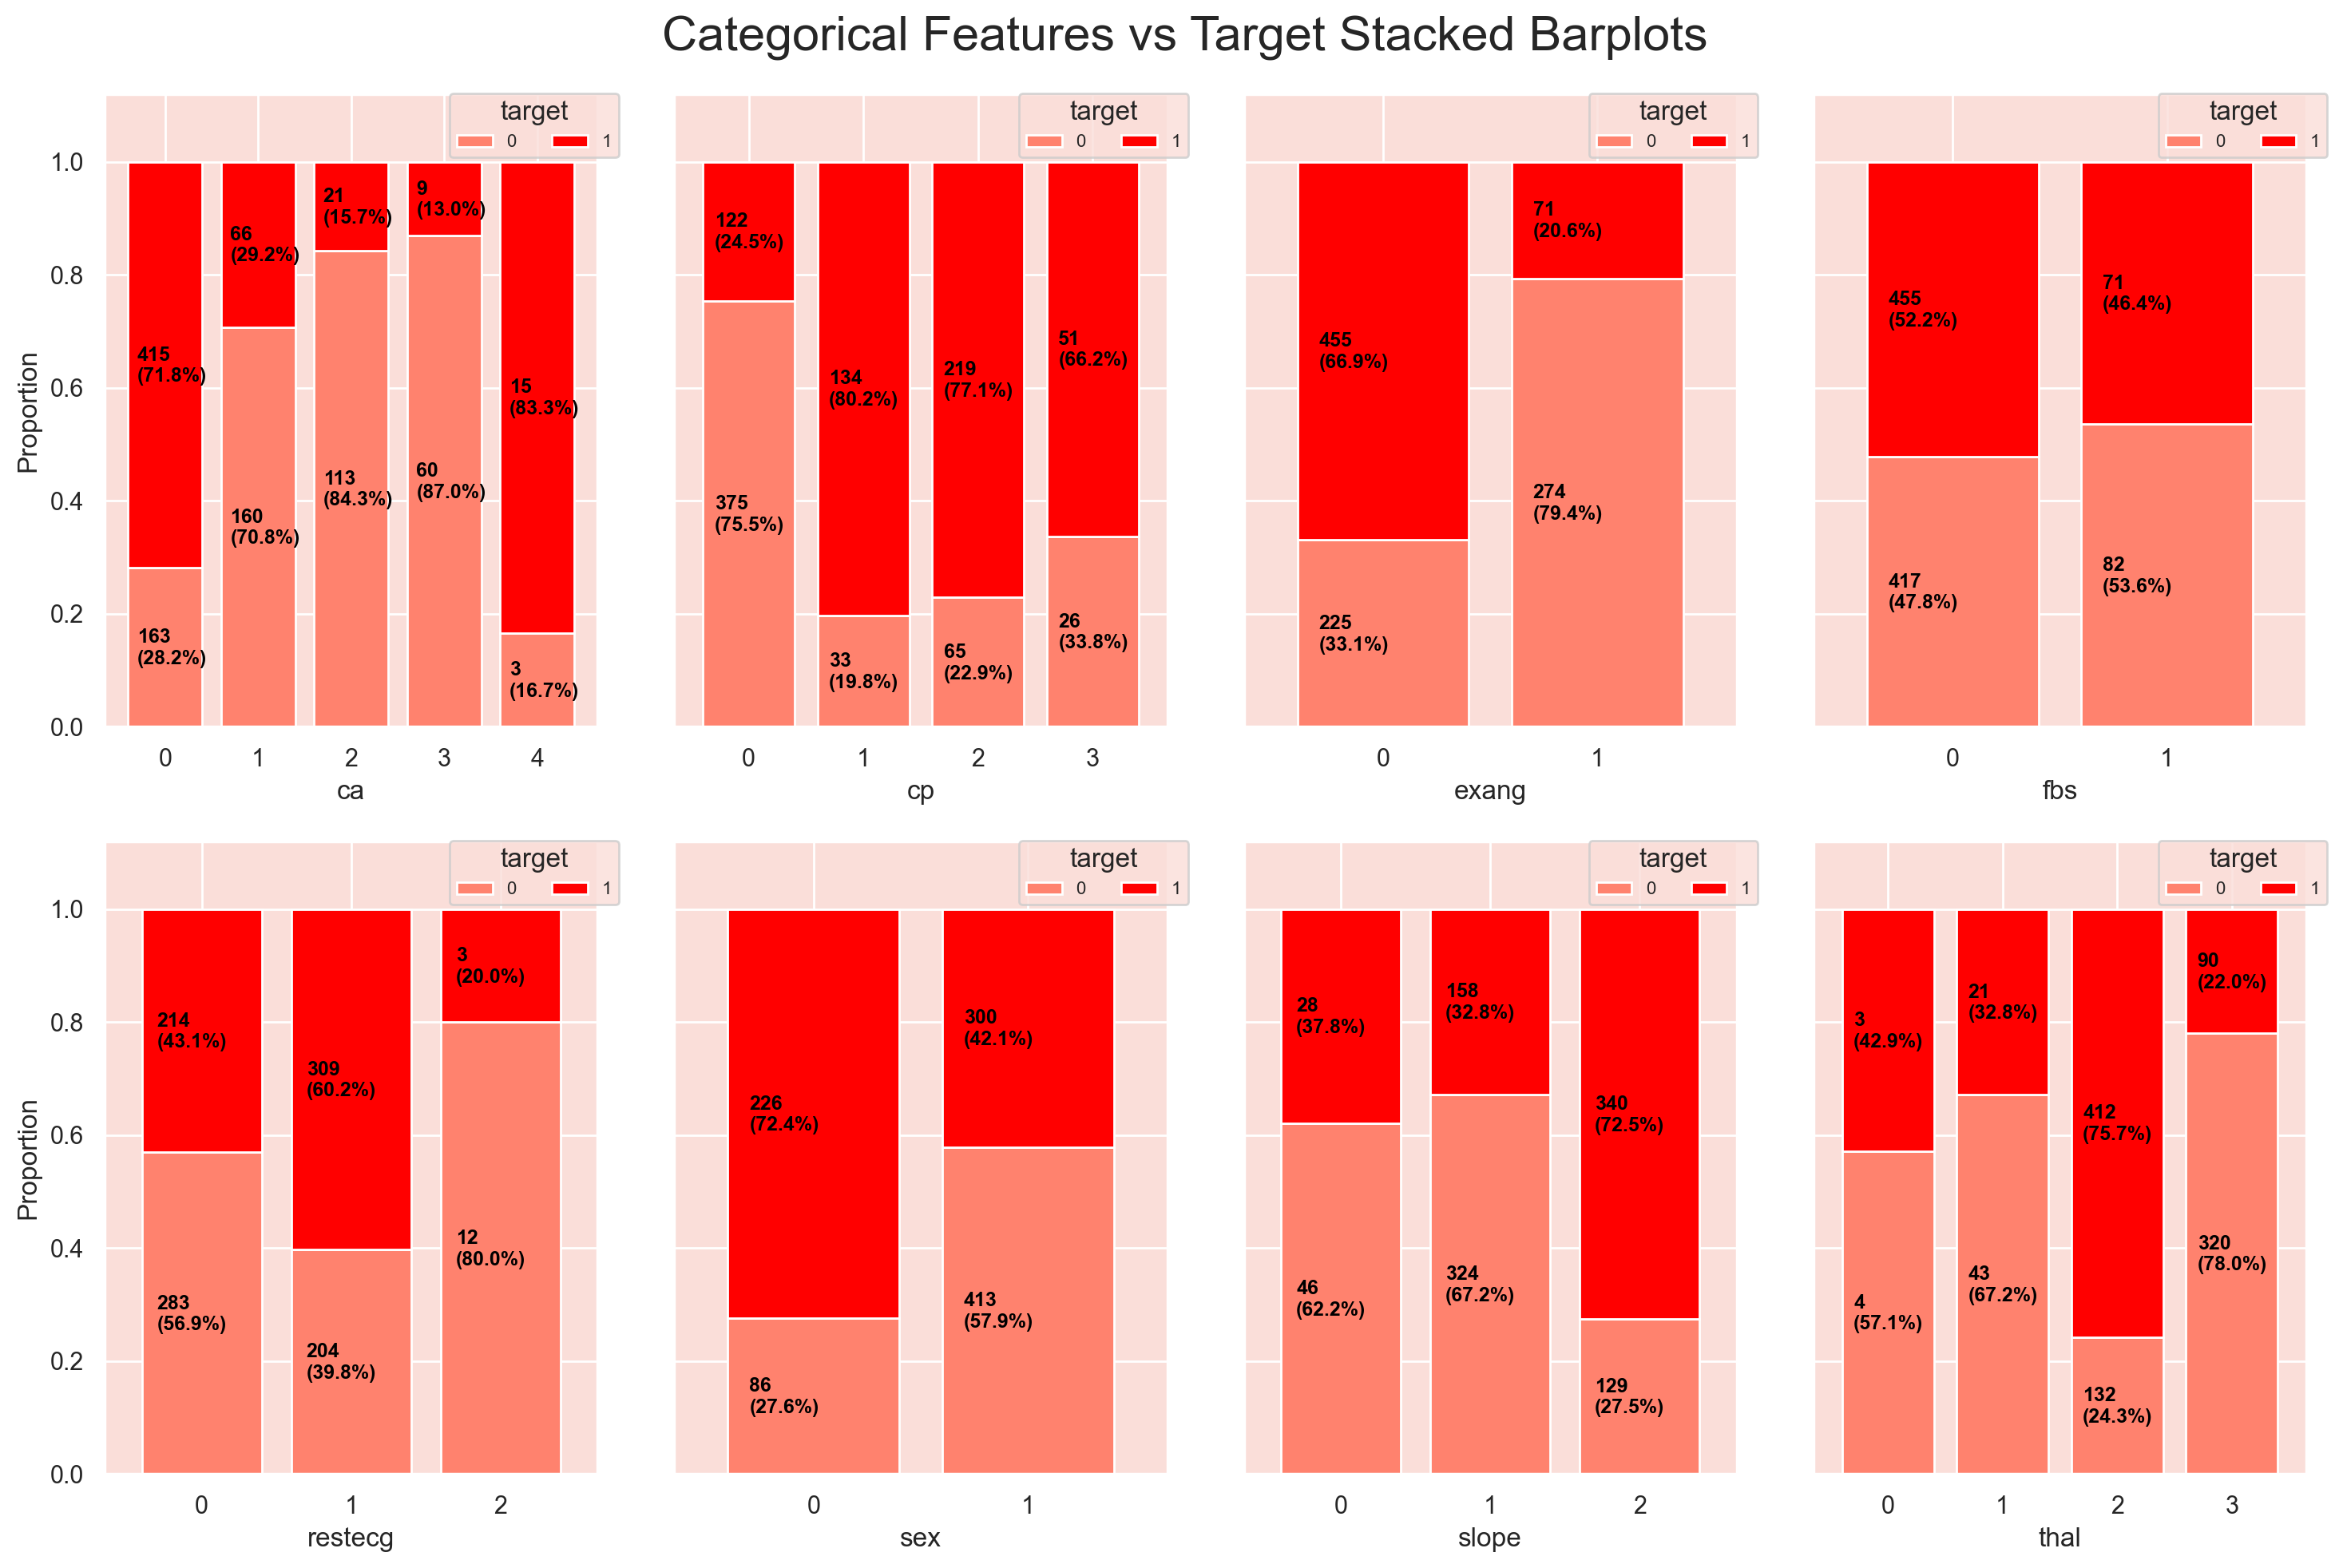

In [21]:
categorical_features = [feature for feature in categorical_features if feature != 'target']

fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(15,10))

for i, col in enumerate(categorical_features):

    cross_tab = pd.crosstab(index=df[col], columns=df['target'])

    cross_tab_prop = pd.crosstab(index=df[col], columns=df['target'], normalize='index')

    cmp = ListedColormap(['#ff826e', 'red'])

    x, y = i//4, i%4

    cross_tab_prop.plot(kind='bar', ax=ax[x,y], stacked=True, width=0.8, colormap=cmp,
                        legend=False, ylabel='Proportion', sharey=True)

    for idx, val in enumerate([*cross_tab.index.values]):
        for (proportion, count, y_location) in zip(
            cross_tab_prop.loc[val],
            cross_tab.loc[val],
            cross_tab_prop.loc[val].cumsum()
        ):
            ax[x,y].text(
                x=idx-0.3,
                y=(y_location-proportion)+(proportion/2)-0.03,
                s=f'{count}\n({np.round(proportion*100,1)}%)',
                color="black",
                fontsize=9,
                fontweight="bold"
            )

    ax[x,y].legend(title='target', loc=(0.7,0.9), fontsize=8, ncol=2)

    ax[x,y].set_ylim([0,1.12])

    ax[x,y].set_xticklabels(ax[x,y].get_xticklabels(), rotation=0)

plt.suptitle('Categorical Features vs Target Stacked Barplots', fontsize=22)
plt.tight_layout()
plt.show()

In [24]:
df.isnull().sum().sum()

np.int64(0)

In [25]:
continuous_features

Q1 = df[continuous_features].quantile(0.25)
Q3 = df[continuous_features].quantile(0.75)
IQR = Q3 - Q1

outliers_count_specified = ((df[continuous_features] < (Q1 - 1.5 * IQR)) | (df[continuous_features] > (Q3 + 1.5 * IQR))).sum()

outliers_count_specified

age          0
trestbps    30
chol        16
thalach      4
oldpeak      7
dtype: int64

In [26]:
df_encoded = pd.get_dummies(df, columns=['cp', 'restecg', 'thal'], drop_first=True)

features_to_convert = ['sex', 'fbs', 'exang', 'slope', 'ca', 'target']

for feature in features_to_convert:
    df_encoded[feature] = df_encoded[feature].astype(int)

df_encoded.dtypes

age            int64
sex            int64
trestbps       int64
chol           int64
fbs            int64
thalach        int64
exang          int64
oldpeak      float64
slope          int64
ca             int64
target         int64
cp_1            bool
cp_2            bool
cp_3            bool
restecg_1       bool
restecg_2       bool
thal_1          bool
thal_2          bool
thal_3          bool
dtype: object

In [28]:
df_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,2,0,False,False,False,True,False,False,False,True
1,53,1,140,203,1,155,1,3.1,0,0,0,False,False,False,False,False,False,False,True
2,70,1,145,174,0,125,1,2.6,0,0,0,False,False,False,True,False,False,False,True
3,61,1,148,203,0,161,0,0.0,2,1,0,False,False,False,True,False,False,False,True
4,62,0,138,294,1,106,0,1.9,1,3,0,False,False,False,True,False,False,True,False


In [29]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

continuous_features

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [30]:
X_train.shape, X_test.shape

((820, 18), (205, 18))

In [31]:
X_train['oldpeak'] = X_train['oldpeak'] + 0.001
X_test['oldpeak'] = X_test['oldpeak'] + 0.001

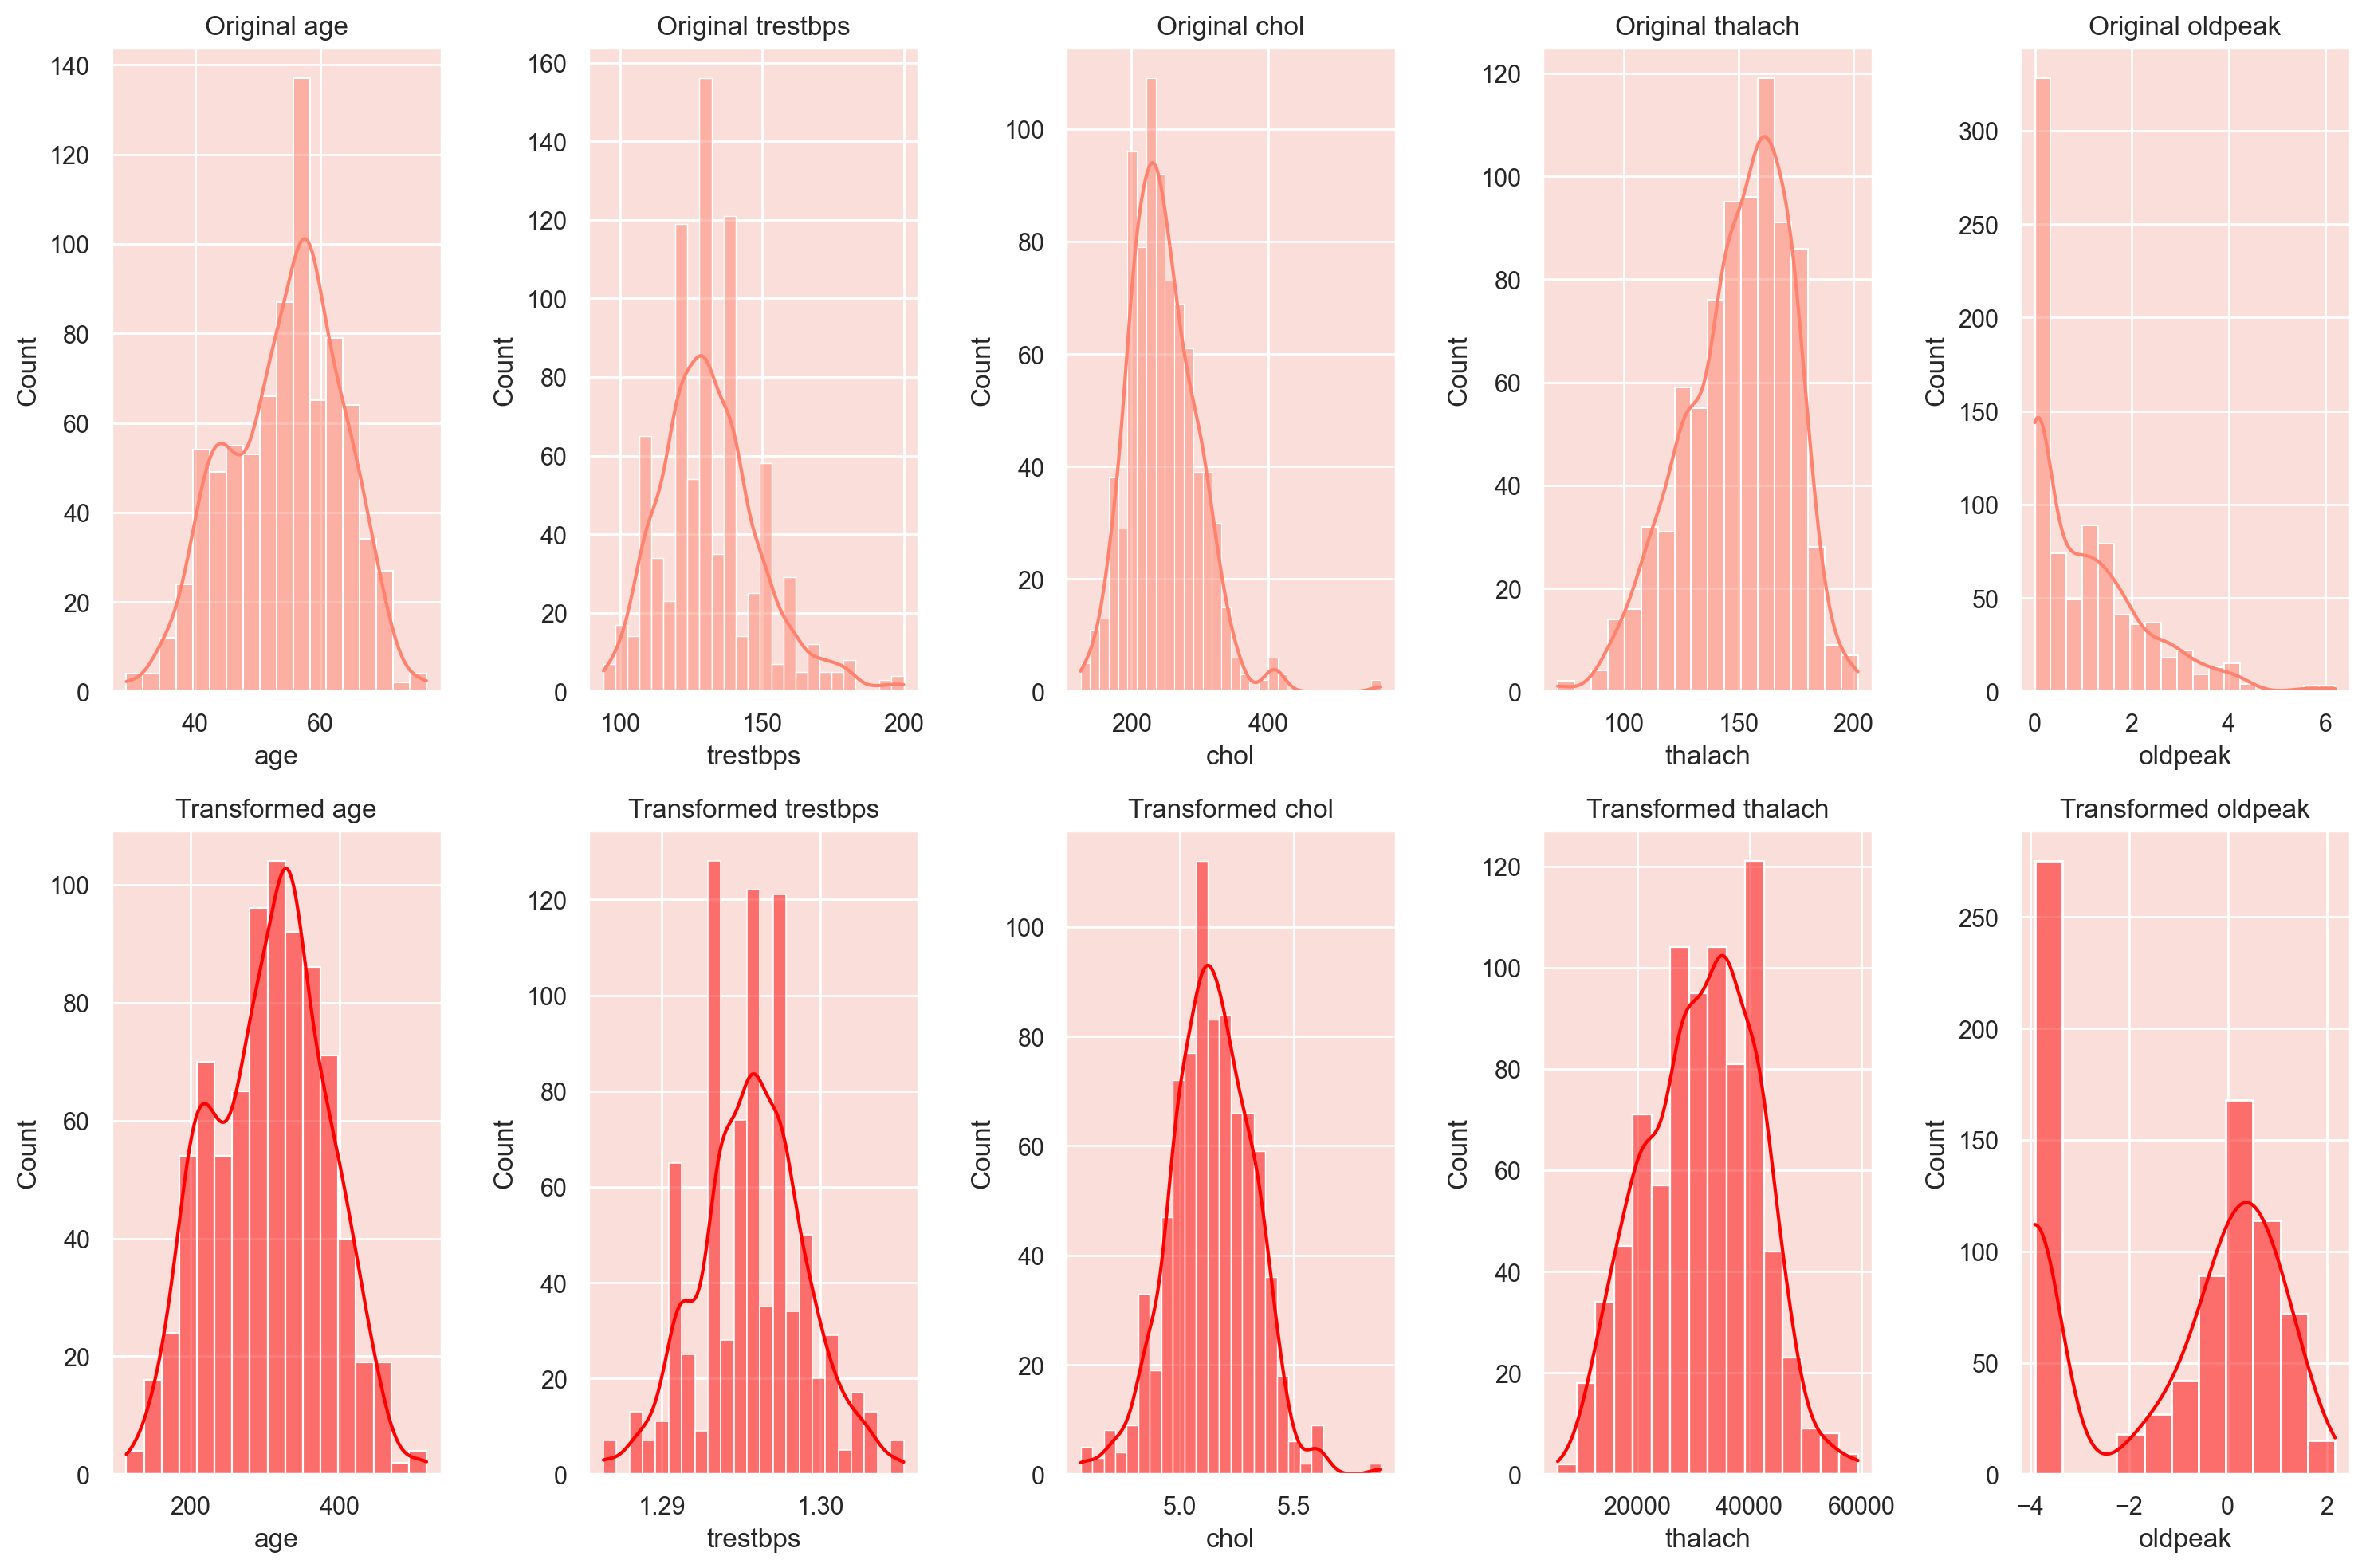

In [32]:
fig, ax = plt.subplots(2, 5, figsize=(15,10))

for i, col in enumerate(continuous_features):
    sns.histplot(X_train[col], kde=True, ax=ax[0,i], color='#ff826e').set_title(f'Original {col}')

lambdas = {}

for i, col in enumerate(continuous_features):
    if X_train[col].min() > 0:
        X_train[col], lambdas[col] = boxcox(X_train[col])
        X_test[col] = boxcox(X_test[col], lmbda=lambdas[col])
        sns.histplot(X_train[col], kde=True, ax=ax[1,i], color='red').set_title(f'Transformed {col}')
    else:
        sns.histplot(X_train[col], kde=True, ax=ax[1,i], color='green').set_title(f'{col} (Not Transformed)')

fig.tight_layout()
plt.show()

In [33]:
X_train.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
397,188.243856,1,1.291178,4.818111,0,16654.592901,1,0.739965,1,0,False,False,False,False,False,False,False,True
687,333.780047,1,1.294735,5.333017,0,40983.789741,0,-3.905686,2,2,False,False,False,False,False,False,False,True
909,265.549657,1,1.298293,4.977381,0,20800.169014,1,-0.103254,1,0,False,False,False,False,False,False,False,True
153,298.985470,1,1.293636,5.201130,0,29291.926122,0,-0.840949,1,0,False,True,False,False,False,False,False,True
373,333.780047,1,1.293636,5.285145,0,35357.536287,0,0.621445,1,0,True,False,False,False,False,False,True,False


In [34]:
dt_base = DecisionTreeClassifier(random_state=0)

In [36]:
def tune_clf_hyperparameters(clf, param_grid, X_train, y_train, scoring='recall', n_splits=3):

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

    clf_grid = GridSearchCV(clf, param_grid, cv=cv, scoring=scoring, n_jobs=-1)

    clf_grid.fit(X_train, y_train)

    best_hyperparameters = clf_grid.best_params_

    return clf_grid.best_estimator_, best_hyperparameters

In [37]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2]
}

best_dt, best_dt_hyperparams = tune_clf_hyperparameters(
    dt_base, param_grid_dt, X_train, y_train
)

print('DT Optimal Hyperparameters: \n', best_dt_hyperparams)

DT Optimal Hyperparameters: 
 {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [38]:
def tune_clf_hyperparameters(clf, param_grid, X_train, y_train, scoring='recall', n_splits=3):

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

    clf_grid = GridSearchCV(clf, param_grid, cv=cv, scoring=scoring, n_jobs=-1)

    clf_grid.fit(X_train, y_train)

    best_hyperparameters = clf_grid.best_params_

    return clf_grid.best_estimator_, best_hyperparameters

In [39]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2]
}

best_dt, best_dt_hyperparams = tune_clf_hyperparameters(dt_base, param_grid_dt, X_train, y_train)

print('DT Optimal Hyperparameters: \n', best_dt_hyperparams)

print(classification_report(y_train, best_dt.predict(X_train)))

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)

    metrics = {
        "precision_0": report["0"]["precision"],
        "precision_1": report["1"]["precision"],
        "recall_0": report["0"]["recall"],
        "recall_1": report["1"]["recall"],
        "f1_0": report["0"]["f1-score"],
        "f1_1": report["1"]["f1-score"],
        "macro_avg_precision": report["macro avg"]["precision"],
        "macro_avg_recall": report["macro avg"]["recall"],
        "macro_avg_f1": report["macro avg"]["f1-score"],
        "accuracy": accuracy_score(y_test, y_pred)
    }

    df = pd.DataFrame(metrics, index=[model_name]).round(2)

    return df

dt_evaluation = evaluate_model(best_dt, X_test, y_test, 'DT')
dt_evaluation

DT Optimal Hyperparameters: 
 {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       399
           1       0.84      0.85      0.85       421

    accuracy                           0.84       820
   macro avg       0.84      0.84      0.84       820
weighted avg       0.84      0.84      0.84       820



,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
DT,0.89,0.87,0.86,0.9,0.87,0.88,0.88,0.88,0.88,0.88


In [40]:
# The dataset contains patient medical attributes such as age, cholesterol, blood pressure, and heart rate.
# During preprocessing, missing values were handled, categorical variables were encoded, and feature scaling was performed using StandardScaler.
# Multiple classification algorithms were applied to predict heart disease.
#Logistic Regression provided good baseline accuracy, Decision Tree showed moderate performance with a risk of overfitting.